## 1. Objective

This notebook establishes baseline model performance before correcting the class imbalance. Logistic regression, decision tree, and random forest models will be trained using the original imbalanced training data and evaluated on the validation set.

F1 is the primary evaluation metric, while AUC-ROC is used to measure the models' ability to rank churned customers above retained customers across classification thresholds. The test set will remain untouched until final evaluation.

## 2. Load processed train and validation sets

In [1]:
from pathlib import Path
import pandas as pd

project_root = (
    Path.cwd().parent
    if Path.cwd().name == 'notebooks'
    else Path.cwd()
)
processed_dir = project_root / 'data' / 'processed'

In [2]:
X_train = pd.read_csv(processed_dir/ 'X_train.csv')
X_val = pd.read_csv(processed_dir/ 'X_val.csv')

y_train = pd.read_csv(processed_dir/ 'y_train.csv')['Exited']
y_val = pd.read_csv(processed_dir/ 'y_val.csv')['Exited']

## 3. Verify shapes, columns, and target proportions

In [3]:
# Verify the imported data

print(f'X_train shape: {X_train.shape}')
print(f'X_val shape: {X_val.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_val shape: {y_val.shape}')

X_train shape: (6000, 11)
X_val shape: (2000, 11)
y_train shape: (6000,)
y_val shape: (2000,)


In [4]:
# Check the columns of the imported data

X_train.columns.tolist()

['CreditScore',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Geography_Germany',
 'Geography_Spain',
 'Gender_Male']

In [5]:
# Integrity check

assert X_train.columns.equals(X_val.columns)
assert X_train.isna().sum().sum() == 0
assert X_val.isna().sum().sum() == 0
assert len(X_train) == len(y_train)
assert len(X_val) == len(y_val)

forbidden_columns = {
    'RowNumber',
    'CustomerId',
    'Surname',
    'Geography',
    'Gender'
}

assert forbidden_columns.isdisjoint(X_train.columns)

print('Training and validation data loaded successfully.')

Training and validation data loaded successfully.


In [6]:
# Check that the original imbalance remains

print('Training target proportions:')
print(y_train.value_counts(normalize=True).round(4))

print('\nValidation target proportions:')
print(y_val.value_counts(normalize=True).round(4))

Training target proportions:
Exited
0    0.7962
1    0.2038
Name: proportion, dtype: float64

Validation target proportions:
Exited
0    0.7965
1    0.2035
Name: proportion, dtype: float64


## 4. Dummy Classifier Baseline

A dummy classifier provides a minimum performance reference. Using the `most_frequent` strategy, it predicts the majority class for every customer without learning relationships between the features and churn.

Because the target is imbalanced, this model may have relatively high accuracy while producing an F1 score of zero for the churn class.

In [7]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay
)

In [8]:
# Train the dummy model using the training data
dummy_model = DummyClassifier(
    strategy='most_frequent',
    random_state=42
)

dummy_model.fit(X_train, y_train)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
Name,Type,Value
"class_prior_ class_prior_: ndarray of shape (n_classes,) or list of such arraysFrequency of each class observed in `y`. For multioutput classificationproblems, this is computed independently for each output.","ndarray[float64](2,)","[0.8,0.2]"
"classes_ classes_: ndarray of shape (n_classes,) or list of such arraysUnique class labels observed in `y`. For multi-output classificationproblems, this attribute is a list of arrays as each output has anindependent set of possible classes.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X` hasfeature names that are all strings.","ndarray[object](11,)","['CreditScore','Age','Tenure',...,'Geography_Germany','Geography_Spain', 'Gender_Male']"
n_classes_ n_classes_: int or list of intNumber of label for each output.,int,2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,11
n_outputs_ n_outputs_: intNumber of outputs.,int,1
sparse_output_ sparse_output_: boolTrue if the array returned from predict is to be in sparse CSC format.Is automatically set to True if the input `y` is passed in sparseformat.,bool,False


In [9]:
# Validation predictions

dummy_predictions = dummy_model.predict(X_val)
dummy_probabilities = dummy_model.predict_proba(X_val)[:, 1]

In [10]:
# Dummy metrics

dummy_results = {
    'Model': 'Dummy Classifier',
    'Accuracy': accuracy_score(y_val, dummy_predictions),
    'Precision': precision_score(
        y_val,
        dummy_predictions,
        zero_division=0
    ),
    'Recall': recall_score(
        y_val,
        dummy_predictions,
        zero_division=0
    ),
    'F1': f1_score(
        y_val,
        dummy_predictions,
        zero_division=0
    ),
    'AUC-ROC': roc_auc_score(
        y_val,
        dummy_probabilities
    )
}

pd.DataFrame([dummy_results]).round(4)

,Model,Accuracy,Precision,Recall,F1,AUC-ROC
0,Dummy Classifier,0.7965,0.0,0.0,0.0,0.5


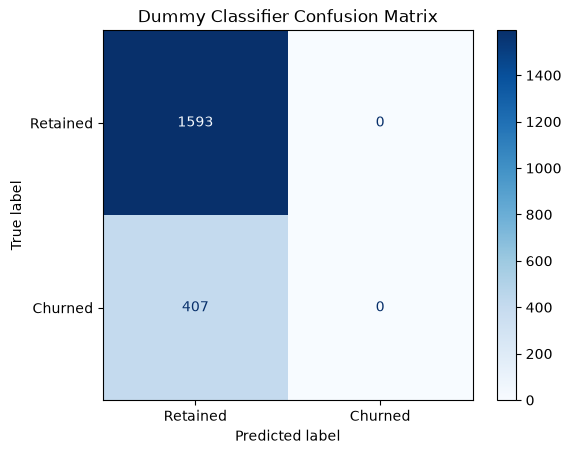

In [11]:
# Confusion matrix

import matplotlib.pyplot as plt
ConfusionMatrixDisplay.from_predictions(
    y_val,
    dummy_predictions,
    display_labels=['Retained', 'Churned'],
    cmap='Blues'
)

plt.title('Dummy Classifier Confusion Matrix')
plt.show()

### Dummy-classifier findings

The dummy classifier achieved approximately 79.7% accuracy because it predicted the majority class for every customer. However, it did not identify any churned customers, resulting in precision, recall, and F1 scores of zero.

Its AUC-ROC score of 0.50 indicates no ability to distinguish churned customers from retained customers. This demonstrates why accuracy alone is misleading for this imbalanced classification problem. A useful trained model must achieve an F1 score above zero and an AUC-ROC above 0.50.

## 5. Logistic regression

Logistic regression provides the first trained baseline model. It estimates the probability that a customer will churn based on a linear combination of the processed features.

No class weighting or resampling is applied in this notebook, allowing us to observe how the original class imbalance affects the model.

In [12]:
# Train the logistic regression model using the training data

from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [13]:
# Validation predictions

logistic_predictions = logistic_model.predict(X_val)
logistic_probabilities = logistic_model.predict_proba(X_val)[:, 1]

In [14]:
# Logistic regression metrics

logistic_results = {
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(
        y_val,
        logistic_predictions
    ),
    'Precision': precision_score(
        y_val,
        logistic_predictions,
        zero_division=0
    ),
    'Recall': recall_score(
        y_val,
        logistic_predictions,
        zero_division=0
    ),
    'F1': f1_score(
        y_val,
        logistic_predictions,
        zero_division=0
    ),
    'AUC-ROC': roc_auc_score(
        y_val,
        logistic_probabilities
    )
}

pd.DataFrame([logistic_results]).round(4)

,Model,Accuracy,Precision,Recall,F1,AUC-ROC
0,Logistic Regression,0.8095,0.5867,0.2162,0.316,0.7562


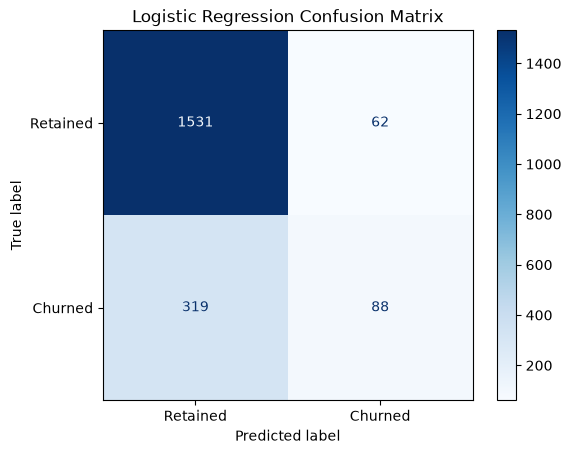

In [15]:
# Confusion matrix

ConfusionMatrixDisplay.from_predictions(
    y_val,
    logistic_predictions,
    display_labels=['Retained', 'Churned'],
    cmap='Blues'
)

plt.title('Logistic Regression Confusion Matrix')
plt.show()

In [16]:
# Compare the results of the dummy model and logistic regression

baseline_results = pd.DataFrame([
    dummy_results,
    logistic_results
])

baseline_results.round(4)

,Model,Accuracy,Precision,Recall,F1,AUC-ROC
0,Dummy Classifier,0.7965,0.0000,0.0000,0.000,0.5000
1,Logistic Regression,0.8095,0.5867,0.2162,0.316,0.7562


### Logistic-regression findings

Logistic regression performed better than the dummy classifier, achieving an F1 score of approximately 0.316 and an AUC-ROC of approximately 0.756.

Its precision of approximately 0.587 indicates that a majority of customers predicted to churn actually churned. However, its recall was only approximately 0.216: the model identified 88 of the 407 churned customers and missed 319.

The relatively high accuracy of approximately 0.810 is influenced by the majority class. The low recall and F1 score indicate that, at the default classification threshold, the imbalanced model favors predicting that customers will remain. Its AUC-ROC suggests that it still has useful ranking ability, which may benefit from imbalance correction or threshold adjustment in a later notebook.

## 6. Decision tree

A decision tree can learn nonlinear relationships and interactions without assuming that their effects are linear.

This baseline tree is trained without class weighting, resampling, pruning, or hyperparameter tuning. Its unrestricted growth also allows us to examine whether the model overfits the training data.

In [17]:
# Train the decision tree model using the training data

from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

decision_tree_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [18]:
# Validation predictions

tree_predictions = decision_tree_model.predict(X_val)
tree_probabilities = decision_tree_model.predict_proba(X_val)[:, 1]

In [19]:
# Decision tree metrics

tree_results = {
    'Model': 'Decision Tree',
    'Accuracy': accuracy_score(
        y_val,
        tree_predictions
    ),
    'Precision': precision_score(
        y_val,
        tree_predictions,
        zero_division=0
    ),
    'Recall': recall_score(
        y_val,
        tree_predictions,
        zero_division=0
    ),
    'F1': f1_score(
        y_val,
        tree_predictions,
        zero_division=0
    ),
    'AUC-ROC': roc_auc_score(
        y_val,
        tree_probabilities
    )
}

pd.DataFrame([tree_results]).round(4)

,Model,Accuracy,Precision,Recall,F1,AUC-ROC
0,Decision Tree,0.7915,0.4877,0.4865,0.4871,0.678


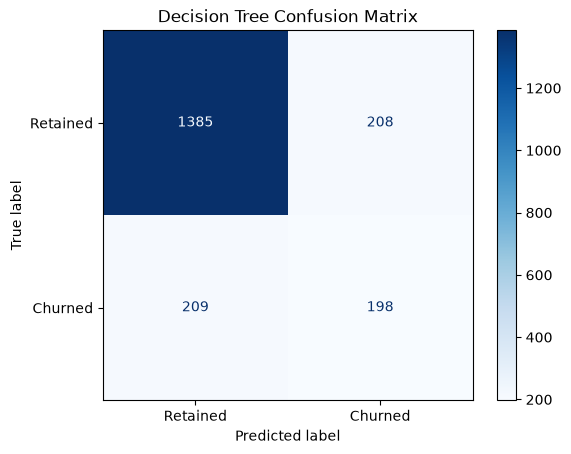

In [20]:
# Confusion matrix

ConfusionMatrixDisplay.from_predictions(
    y_val,
    tree_predictions,
    display_labels=['Retained', 'Churned'],
    cmap='Blues'
)

plt.title('Decision Tree Confusion Matrix')
plt.show()

In [21]:
# Tree complexity

print(f'Tree depth: {decision_tree_model.get_depth()}')
print(f'Number of leaves: {decision_tree_model.get_n_leaves()}')

Tree depth: 23
Number of leaves: 870


In [22]:
# Check for overfitting (compare training and validation F1)

tree_train_predictions = decision_tree_model.predict(X_train)

tree_train_f1 = f1_score(
    y_train,
    tree_train_predictions
)

tree_validation_f1 = f1_score(
    y_val,
    tree_predictions
)

print(f'Training F1: {tree_train_f1:.4f}')
print(f'Validation F1: {tree_validation_f1:.4f}')



Training F1: 1.0000
Validation F1: 0.4871


In [23]:
# Comparison table updated

baseline_results = pd.DataFrame([
    dummy_results,
    logistic_results,
    tree_results
])

baseline_results.round(4)

,Model,Accuracy,Precision,Recall,F1,AUC-ROC
0,Dummy Classifier,0.7965,0.0000,0.0000,0.0000,0.5000
1,Logistic Regression,0.8095,0.5867,0.2162,0.3160,0.7562
2,Decision Tree,0.7915,0.4877,0.4865,0.4871,0.6780


### Decision-tree findings

The unrestricted decision tree achieved a validation F1 score of approximately 0.487, outperforming logistic regression's F1 of approximately 0.316. Its recall increased substantially to approximately 0.486, meaning it identified 198 of the 407 churned validation customers.

However, its precision was approximately 0.488, indicating that roughly half of its churn predictions were incorrect. Its AUC-ROC of approximately 0.678 was also lower than logistic regression's 0.756, suggesting that logistic regression ranked customers by churn risk more effectively across thresholds.

The tree reached a depth of approximately 23 with 870 leaves and achieved perfect training performance, while its validation F1 remained below 0.50. This large training-validation gap indicates substantial overfitting. Tree depth and other complexity parameters will be tuned later; no correction is applied during baseline modeling.

## 7. Random forest

A random forest combines predictions from multiple decision trees trained on different bootstrap samples and feature subsets. This generally reduces the variance and overfitting associated with a single decision tree.

This baseline uses the default hyperparameters and does not apply class weighting, resampling, or threshold adjustment.

In [24]:
# Train the random forest model using the training data

from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    random_state=42,
)
random_forest_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [25]:
# Validation predictions

forest_predictions = random_forest_model.predict(X_val)
forest_probabilities = random_forest_model.predict_proba(X_val)[:, 1]

In [26]:
# Metrics for the random forest model

forest_results = {
    'Model': 'Random Forest',
    'Accuracy': accuracy_score(
        y_val,
        forest_predictions
    ),
    'Precision': precision_score(
        y_val,
        forest_predictions,
        zero_division=0
    ),
    'Recall': recall_score(
        y_val,
        forest_predictions,
        zero_division=0
    ),
    'F1': f1_score(
        y_val,
        forest_predictions,
        zero_division=0
    ),
    'AUC-ROC': roc_auc_score(
        y_val,
        forest_probabilities
    )
}

pd.DataFrame([forest_results]).round(4)


,Model,Accuracy,Precision,Recall,F1,AUC-ROC
0,Random Forest,0.8665,0.7917,0.4668,0.5873,0.8548


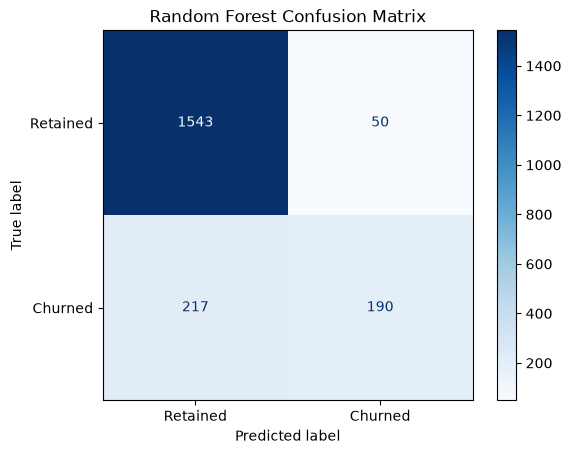

In [27]:
# Confusion matrix

ConfusionMatrixDisplay.from_predictions(
    y_val,
    forest_predictions,
    display_labels=['Retained', 'Churned'],
    cmap='Blues'
)

plt.title('Random Forest Confusion Matrix')
plt.show()

In [28]:
# Check for overfitting

forest_train_predictions = random_forest_model.predict(X_train)

forest_train_f1 = f1_score(
    y_train,
    forest_train_predictions
)

forest_validation_f1 = f1_score(
    y_val,
    forest_predictions
)

print(f'Training F1: {forest_train_f1:.4f}')
print(f'Validation F1: {forest_validation_f1:.4f}')

Training F1: 1.0000
Validation F1: 0.5873


In [29]:
# Comparison table updated

baseline_results = pd.DataFrame([
    dummy_results,
    logistic_results,
    tree_results,
    forest_results
])

baseline_results.sort_values(
    by='F1',
    ascending=False
).round(4)

,Model,Accuracy,Precision,Recall,F1,AUC-ROC
3,Random Forest,0.8665,0.7917,0.4668,0.5873,0.8548
2,Decision Tree,0.7915,0.4877,0.4865,0.4871,0.6780
1,Logistic Regression,0.8095,0.5867,0.2162,0.3160,0.7562
0,Dummy Classifier,0.7965,0.0000,0.0000,0.0000,0.5000


### Random-forest findings

The random forest produced the strongest baseline performance, achieving a validation F1 score of approximately 0.587 and an AUC-ROC of approximately 0.855.

Its precision of approximately 0.792 was considerably higher than that of the other trained baseline models, meaning most customers it classified as churners actually churned. Its recall was approximately 0.467, so it still missed 217 of the 407 churned customers.

Although its validation F1 is just below the project's required final test score of 0.59, the model has not yet been tuned and the class imbalance has not been addressed. Its perfect training F1 also suggests overfitting. Random forest is therefore the strongest candidate for hyperparameter tuning and imbalance correction in the next notebook.

## 8. Validation evaluation 

The four baseline models are compared using the same validation set. F1 is the primary selection metric because the target is imbalanced, while AUC-ROC measures each model's ability to rank churned customers above retained customers across classification thresholds.

Accuracy is retained for context but is not used as the primary model-selection metric.

In [30]:
validation_results = (
    pd.DataFrame([
        dummy_results,
        logistic_results,
        tree_results,
        forest_results
    ])
    .sort_values(by='F1', ascending=False)
    .reset_index(drop=True)
)

validation_results.round(4)

,Model,Accuracy,Precision,Recall,F1,AUC-ROC
0,Random Forest,0.8665,0.7917,0.4668,0.5873,0.8548
1,Decision Tree,0.7915,0.4877,0.4865,0.4871,0.6780
2,Logistic Regression,0.8095,0.5867,0.2162,0.3160,0.7562
3,Dummy Classifier,0.7965,0.0000,0.0000,0.0000,0.5000


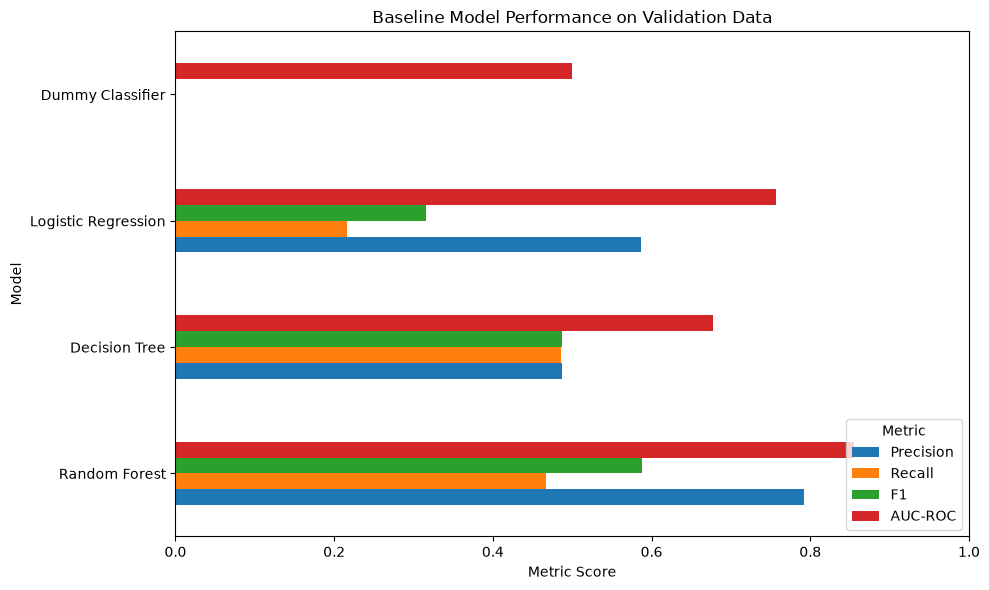

In [31]:
comparison_metrics = [
    'Precision',
    'Recall',
    'F1',
    'AUC-ROC'
]

ax = (
    validation_results
    .set_index('Model')[comparison_metrics]
    .plot(
        kind='barh',
        figsize=(10, 6)
    )
)

ax.set_title('Baseline Model Performance on Validation Data')
ax.set_xlabel('Metric Score')
ax.set_ylabel('Model')
ax.set_xlim(0, 1)
ax.legend(title='Metric', loc='lower right')

plt.tight_layout()
plt.show()

### Validation findings

The random forest produced the strongest overall validation performance. It achieved the highest F1 score (0.587), AUC-ROC (0.855), precision (0.792), and accuracy (0.867) among the trained baseline models.

The decision tree achieved slightly higher recall than the random forest (0.486 versus 0.467), but its lower precision and AUC-ROC resulted in weaker overall performance. Its perfect training F1 and substantially lower validation F1 also indicate considerable overfitting.

Logistic regression achieved an AUC-ROC of 0.756, indicating useful ranking ability, but its recall of 0.216 was low at the default classification threshold. It predicted the majority class too frequently and missed most churned customers.

The dummy classifier demonstrated why accuracy is unsuitable as the primary metric. Despite achieving approximately 79.7% accuracy, it failed to identify a single churned customer and had an F1 score of zero.

None of the unbalanced baseline models exceeded an F1 score of 0.59 on the validation set. The random forest came closest at 0.587 and is the strongest initial candidate for imbalance correction and hyperparameter tuning. Logistic regression may also benefit from class weighting or threshold adjustment because of its comparatively strong AUC-ROC.

## 9. Baseline conclusions

This notebook evaluated four models without correcting the class imbalance:

- The dummy classifier predicted only the majority class and produced an F1 score of zero.
- Logistic regression ranked customers reasonably well but identified relatively few churned customers at the default threshold.
- The unrestricted decision tree improved recall and F1 but substantially overfit the training data.
- The random forest provided the strongest validation performance, with an F1 score of 0.587 and an AUC-ROC of 0.855.

These results confirm that the original class imbalance influences the models' ability to identify churned customers. The next stage will test at least two imbalance-handling approaches, including class weighting and resampling, while tuning model hyperparameters using the training and validation sets.

The test set has not been used and will remain untouched until final evaluation.